# Data Cleaning Practice — Loan Dataset

Hands-on companion to `04_Data_Cleaning.MD`, sub-skill #1: **Handling Missing Data**.

Dataset: `loans.csv` — 618 loan applications, 13 columns (Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area, Loan_Status, and the Loan_ID key).

Goal for this notebook: **find out where the missing values are**, before deciding what to do about them.

In [1]:
import pandas as pd

## 1. Load the dataset

In [2]:
dataset = pd.read_csv("loans.csv")
dataset.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,Yes,0,Not Graduate,No,1686.0,1020,80.0,360.0,1.0,Semiurban,Y
1,LP001002,Male,Yes,0,Not Graduate,No,2437.0,1201,122.0,360.0,1.0,Urban,Y
2,LP001003,Female,No,0,Graduate,No,8313.0,1065,319.0,360.0,1.0,Urban,Y
3,LP001004,Male,Yes,0,Graduate,No,5069.0,0,218.0,360.0,1.0,Semiurban,Y
4,LP001005,Male,No,2,Graduate,No,3002.0,2283,194.0,360.0,0.0,Urban,N
5,LP001006,Female,Yes,0,Graduate,No,3918.0,1966,219.0,360.0,1.0,NaN,Y
6,LP001007,Male,No,0,Graduate,No,4255.0,2274,205.0,360.0,1.0,Rural,Y
7,LP001008,NaN,Yes,0,Not Graduate,Yes,5890.0,2699,305.0,360.0,1.0,Urban,Y
8,LP001009,Male,No,0,Not Graduate,No,2296.0,1371,104.0,360.0,1.0,Semiurban,Y
9,LP001010,Male,Yes,0,Graduate,No,2897.0,4815,228.0,240.0,1.0,Semiurban,Y


## 2. Shape — how many rows and columns?

In [3]:
dataset.shape

(618, 13)

## 3. Which columns have missing values, and how many?

`isnull()` marks every cell `True`/`False`, `.sum()` adds those up per column.

In [4]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               6
Dependents           15
Education             9
Self_Employed        32
ApplicantIncome       2
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     21
Credit_History       50
Property_Area         9
Loan_Status           0
dtype: int64

## 4. Missing values as a percentage of each column

Raw counts are hard to compare across columns of different sizes — percentage puts every column on the same scale.

In [5]:
(dataset.isnull().sum() / dataset.shape[0]) * 100

Loan_ID              0.000000
Gender               2.103560
Married              0.970874
Dependents           2.427184
Education            1.456311
Self_Employed        5.177994
ApplicantIncome      0.323625
CoapplicantIncome    0.000000
LoanAmount           3.559871
Loan_Amount_Term     3.398058
Credit_History       8.090615
Property_Area        1.456311
Loan_Status          0.000000
dtype: float64

## 5. Overall — what % of the *entire* dataset is missing?

`dataset.shape[0] * dataset.shape[1]` is the total number of cells (rows × columns); `.isnull().sum().sum()` is the total number of missing cells across every column.

In [6]:
(dataset.isnull().sum().sum() / (dataset.shape[0] * dataset.shape[1])) * 100

np.float64(2.2280308688075676)

## 6. Visualize the missing values

Numbers tell you *how much* is missing; a picture tells you *where* — whether the gaps are scattered randomly or clustered in specific rows or columns. Two views below: a full heatmap of every cell, and a bar chart ranking the columns that actually have gaps.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

### Heatmap — do columns go missing together?

A raw row-by-row map of all 618 rows gets visually noisy and doesn't render cleanly as a static image at that many rows. A more useful view instead: **nullity correlation** — does missingness in one column tend to happen alongside missingness in another? Near 0 = no relationship; near +1 = the two columns tend to be missing on the same rows; near −1 = when one is missing, the other tends to be present.

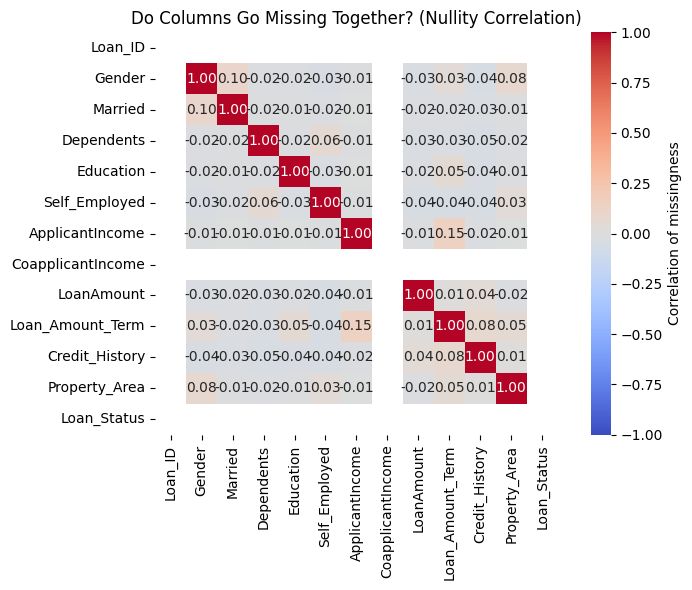

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    dataset.isnull().corr(), annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, square=True,
    cbar_kws={"label": "Correlation of missingness"},
)
plt.title("Do Columns Go Missing Together? (Nullity Correlation)")
plt.tight_layout()
plt.show()

### Bar chart — which columns are worst?

Same numbers as `isnull().sum()` above, ranked so the worst offender is impossible to miss.

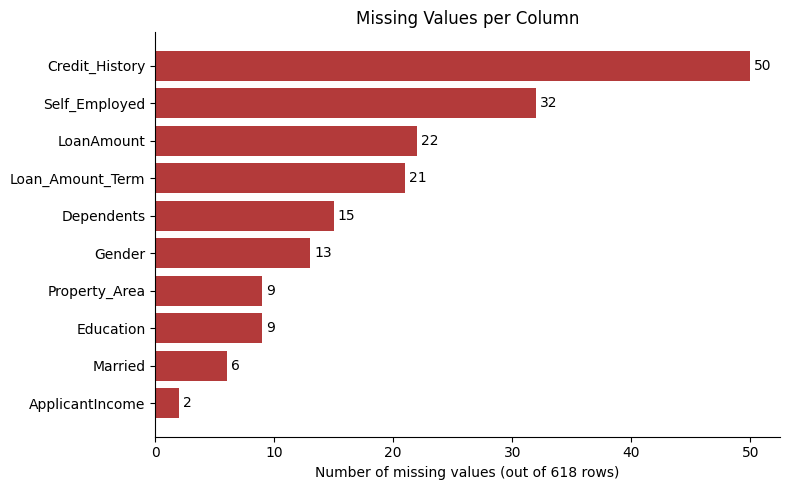

In [9]:
missing_counts = dataset.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(missing_counts.index, missing_counts.values, color="#b33a3a")
plt.bar_label(bars, padding=3)
plt.xlabel("Number of missing values (out of 618 rows)")
plt.title("Missing Values per Column")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7. The 50% Rule — when a column isn't worth saving

Imputing a column that's more than half missing means inventing more data than you actually observed — past a certain point, dropping the column outright is more honest than filling it. Common rule of thumb: if a column is **≥ 50% missing, ignore (drop) it** rather than impute it.

In [10]:
def flag_high_missing_columns(df, threshold=50):
    """Return columns whose missing-value percentage is >= threshold, worst first."""
    missing_pct = (df.isnull().sum() / df.shape[0]) * 100
    return missing_pct[missing_pct >= threshold].sort_values(ascending=False)

high_missing = flag_high_missing_columns(dataset, threshold=50)

if high_missing.empty:
    print("No column crosses the 50% threshold — nothing to ignore on this rule.")
else:
    print("Columns to ignore (>= 50% missing):")
    print(high_missing)

No column crosses the 50% threshold — nothing to ignore on this rule.


In [11]:
dataset_cleaned = dataset.drop(columns=high_missing.index)

print("Shape before:", dataset.shape)
print("Shape after dropping high-missing columns:", dataset_cleaned.shape)

Shape before: (618, 13)
Shape after dropping high-missing columns: (618, 13)


Worst column here (`Credit_History`) is only ~8% missing — nowhere near the 50% line, so the rule doesn't drop anything from *this* dataset, and `dataset_cleaned` above is identical to `dataset`. That's the correct outcome, not a wasted check: this guard is what you'd want running automatically before feature engineering on messier real-world data, where some column blowing past 50% missing is common — better to have it silently do nothing here than to have to remember to add it later when it actually matters.

## Reading the result

- **`Credit_History`** is the worst-affected column (~8% missing) — and it's also usually the single strongest predictor of `Loan_Status` in this kind of dataset, so this is the column worth the most care, not the least.
- **`Self_Employed`** (~5% missing) is next — a categorical column, so mean/median imputation doesn't apply; mode (most frequent category) is the usual starting point.
- **`CoapplicantIncome`** and **`Loan_Status`** have zero missing — nothing to do there (and note they, along with `Loan_ID`, show up blank in the correlation heatmap — correlation is undefined for a column with zero variance, i.e. nothing ever missing).
- Overall, ~2.2% of all cells in the dataset are missing — a small fraction, but concentrated unevenly across columns rather than spread evenly, which is the normal case in real data.
- The nullity correlation heatmap is essentially all near 0 — missingness in one column doesn't predict missingness in another here, i.e. each column's gaps look like independent, unrelated causes rather than one shared root problem (e.g. one bad data-entry batch that blanked out several fields at once).
- Applying the **50% ignore-rule** from section 7 removes zero columns here — every column is well under the line — so `dataset_cleaned` is safe to carry forward as-is into imputation, with no columns needing to be dropped outright first.

**Next up:** deciding *how* to fill each of these in — drop, mean/median (numeric), mode (categorical), or a model-based imputer — which is where `04_Data_Cleaning.MD`'s Handling Missing Data section picks back up.

## 8. Filling the Missing Values

Full walkthrough in `07_Filling_Missing_Values.MD` — this is that note's code, run for real against `dataset_cleaned` (the column-checked dataframe from Section 7). Categorical columns get their mode; numerical columns get their median, except `Credit_History`, which is a 0/1 flag stored as a number, not a real continuous quantity — it gets mode too.

In [12]:
categorical_cols = dataset_cleaned.select_dtypes(include="str").columns

for col in categorical_cols:
    dataset_cleaned[col] = dataset_cleaned[col].fillna(dataset_cleaned[col].mode()[0])

dataset_cleaned[categorical_cols].isnull().sum()

Loan_ID          0
Gender           0
Married          0
Dependents       0
Education        0
Self_Employed    0
Property_Area    0
Loan_Status      0
dtype: int64

Every categorical column is now at 0 missing. Note the reassignment pattern (`dataset_cleaned[col] = ...fillna(...)`) rather than `inplace=True` — see `07_Filling_Missing_Values.MD` for why the `inplace=True` version from the course slide silently fails under pandas 3.0's Copy-on-Write.

In [13]:
numerical_cols = dataset_cleaned.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    if col == "Credit_History":
        dataset_cleaned[col] = dataset_cleaned[col].fillna(dataset_cleaned[col].mode()[0])
    else:
        dataset_cleaned[col] = dataset_cleaned[col].fillna(dataset_cleaned[col].median())

dataset_cleaned[numerical_cols].isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
dtype: int64

Every numerical column is at 0 missing too — `Credit_History` filled with its mode (the more common of 0/1), everything else filled with its median.

In [14]:
dataset_cleaned.isnull().sum().sum()   # 0 = fully filled

np.int64(0)

### Visualizing the change

The clearest way to show what filling actually did: the same per-column missing-count bar chart from Section 6, before and after, side by side.

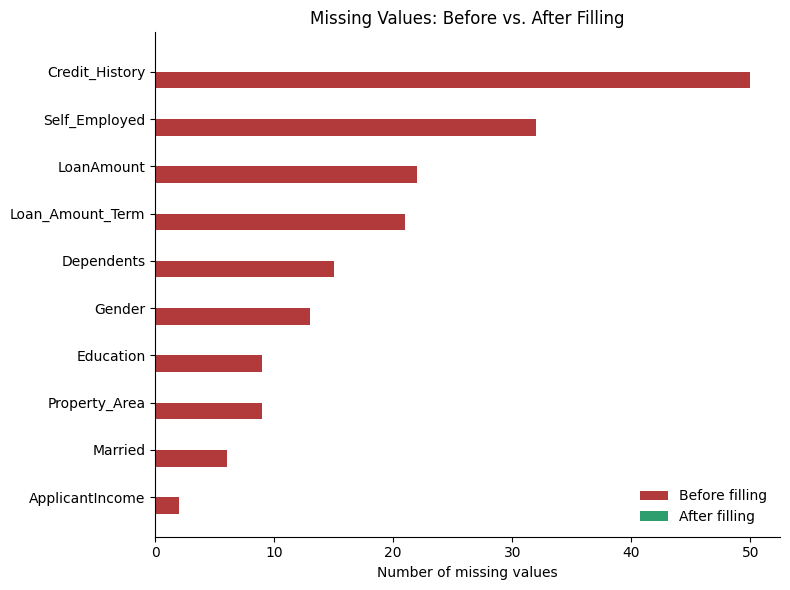

In [15]:
before_counts = dataset.isnull().sum()
after_counts = dataset_cleaned.isnull().sum()
cols = before_counts[before_counts > 0].sort_values(ascending=False).index

y = range(len(cols))
height = 0.35

plt.figure(figsize=(8, 6))
plt.barh([i + height / 2 for i in y], before_counts[cols].values, height=height, color="#b33a3a", label="Before filling")
plt.barh([i - height / 2 for i in y], after_counts[cols].values, height=height, color="#2f9e6f", label="After filling")
plt.yticks(list(y), cols)
plt.gca().invert_yaxis()
plt.xlabel("Number of missing values")
plt.title("Missing Values: Before vs. After Filling")
plt.legend(frameon=False)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Reading the result (Section 8)

- Every column that had gaps in Section 3 now reads 0 in the "after" bars — `dataset_cleaned` is fully filled, 618 rows × 13 columns, no missing values anywhere.
- `Credit_History` (the worst column at ~8%) and `Self_Employed` (~5%) were the tallest "before" bars and are now flat — the two columns most worth double-checking if this were a real modeling project, since imputed values are still guesses, not observations.
- This `dataset_cleaned` dataframe is what would move on to Feature Engineering next (`02_ML_Roadmap.MD` Topic 3) — encoding the categorical columns and scaling the numerical ones.